microclone --- demo 

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

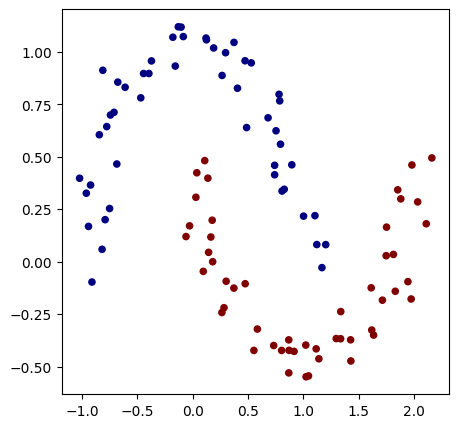

In [5]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [6]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [8]:
def loss(batch_size=None):
    if batch_size == None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb[ri], y[ri]
    inputs = [list(map(Value, xrow))for xrow in Xb]

    scores = list(map(model, inputs))

    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)] 
    data_loss = sum(losses) * (1.0 / len(losses)) 

    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))

    total_loss = data_loss + reg_loss

    accuracy = [(yi > 0)== (scorei.data > 0 )for yi, scorei in zip(yb,scores)]
    return total_loss, sum(accuracy) / len(accuracy) 

total_loss, acc = loss() 
print(total_loss, acc) 





Value(data=0.8958441028683222, grad=0) 0.5


In [9]:
for k in range(100):

    total_loss, acc = loss() 

    model.zero_grad() 
    total_loss.backward() 

    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 1 == 0:
        print(f"step{k} loss {total_loss.data}, accuracy {acc*100}")

    

step0 loss 0.8958441028683222, accuracy 50.0
step1 loss 1.723590533697202, accuracy 81.0
step2 loss 0.7429006313851131, accuracy 77.0
step3 loss 0.7705641260584202, accuracy 82.0
step4 loss 0.3692793385976538, accuracy 84.0
step5 loss 0.3135454819185219, accuracy 86.0
step6 loss 0.2814234349772435, accuracy 89.0
step7 loss 0.2688873331398391, accuracy 91.0
step8 loss 0.2567147286057416, accuracy 91.0
step9 loss 0.27048625516379227, accuracy 91.0
step10 loss 0.2450702385365804, accuracy 91.0
step11 loss 0.2509905529791504, accuracy 92.0
step12 loss 0.21560951851922946, accuracy 91.0
step13 loss 0.23090378446402737, accuracy 93.0
step14 loss 0.20152151227899445, accuracy 92.0
step15 loss 0.22574506279282222, accuracy 93.0
step16 loss 0.19447987596204103, accuracy 92.0
step17 loss 0.21089496199246371, accuracy 93.0
step18 loss 0.15983077356303604, accuracy 94.0
step19 loss 0.1845374874688393, accuracy 93.0
step20 loss 0.1897752285608764, accuracy 91.0
step21 loss 0.19072704042579647, accu

(-1.548639298268643, 1.951360701731357)

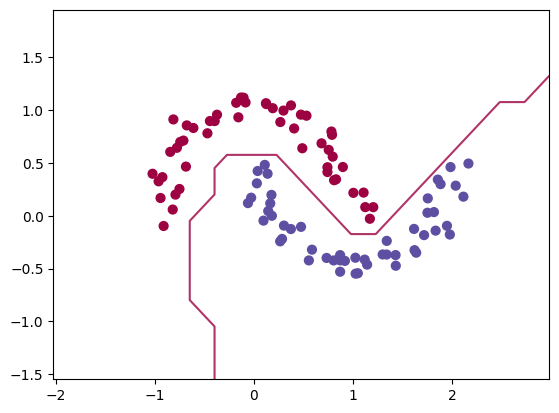

In [11]:
## visualization of (statistical) decision boundary 

h = 0.25 
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), 
np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs)) 
Z = np.array([s.data > 0 for s in scores]) 
Z = Z.reshape(xx.shape) 

fig = plt.figure()
plt.contour(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral) 
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max()) 

